## Pandas + SNS + Maplotlib

In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import math
import random
import csv
import json
import seaborn as sns

## Data ingestion

In [12]:
path_deliveries = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\IPL\\archive\\deliveries.csv"
path_matches = "C:\\Users\\pmoh3005\\OneDrive - 7-Eleven, Inc\\Desktop\\development\\7-11apps\\IPL\\archive\\matches.csv"

In [13]:
deliveries = pd.read_csv(path_deliveries)
matches = pd.read_csv(path_matches)

In [15]:
df = pd.DataFrame(deliveries)
# print(df.head())
print(f"Shape = {df.shape}")
print(f"Columns = {df.columns}")
df.head()

Shape = (260920, 17)
Columns = Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


## SNS and plt init

In [17]:
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#333',
    'legend.facecolor': '#1a1a2e',
    'legend.labelcolor': 'white'
})
IPL_COLORS = ['#f7941d', '#00bfff', '#00e676', '#ff4081', '#ce93d8',
              '#ffee58', '#80deea', '#ef9a9a', '#a5d6a7', '#ffe082']

# os.makedirs('output', exist_ok=True) # for all the images / grpahs

## Data cleaning

In [18]:
# Drop the unused columns 
df = df.drop(columns=["dismissal_kind","fielder","is_wicket","extras_type","player_dismissed"])

In [19]:
print(f"Shape = {df.shape}")
print(f"New Columns = {df.columns}")
df.head()

Shape = (260920, 12)
New Columns = Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs'],
      dtype='str')


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0


## Data  Validation

In [ ]:
# check nulls
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0] # flag check
print('Missing Values:')
print(missing_report if not missing_report.empty else 'None — clean dataset')


Missing Values:
None — clean dataset


In [21]:
# match ids uniqueness
size_of_data = len(df["match_id"])
all_match_ids = df["match_id"].unique()
print(size_of_data == len(all_match_ids)) # right numbe rof balls 

False


In [22]:
innings = df["inning"].unique()
print(innings) # 6 innings cause super over 

[1 2 3 4 5 6]


In [23]:
# teams uniqueness 
teams = df["batting_team"].unique()
print(teams)

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bangalore',
         'Chennai Super Kings',             'Kings XI Punjab',
            'Rajasthan Royals',            'Delhi Daredevils',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str


In [25]:
# have to generalize some teams same logic as used in numpy
# My defaults set for all
name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
# batting_team = np.array([name_map.get(t,t) for t in batting_team])
df["batting_team"] = df["batting_team"].replace(name_map)

new_filtered_teams = df["batting_team"].unique()
print(new_filtered_teams)

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
         'Chennai Super Kings',                'Punjab Kings',
            'Rajasthan Royals',              'Delhi Capitals',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',        'Lucknow Super Giants',
              'Gujarat Titans']
Length: 15, dtype: str


In [24]:
# ints all so that we dont have to keep astyping
df['match_id']      = df['match_id'].astype(int)
df['over']          = df['over'].astype(int)
df['ball']          = df['ball'].astype(int)
df['batsman_runs']  = df['batsman_runs'].astype(int)
df['extra_runs']    = df['extra_runs'].astype(int)
df['total_runs']    = df['total_runs'].astype(int)

# Data Transforms as per som euse cases req

In [29]:
# new cols added 
df['is_four']     = (df['batsman_runs'] == 4).astype(int)
df['is_six']      = (df['batsman_runs'] == 6).astype(int)
df['is_boundary'] = df['is_four'] | df['is_six'] # Or both to a flag 
df['is_dot']      = (df['batsman_runs'] == 0).astype(int)
df['is_powerplay']  = df['over'].between(0, 5).astype(int)
df['is_death_over'] = df['over'].between(15, 19).astype(int)

print(f'New Shape: {df.shape}')
df.head()

New Shape: (260920, 18)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,is_four,is_six,is_boundary,is_dot,is_powerplay,is_death_over
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,0,0,0,1,1,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,0,0,0,1,1,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0


In [47]:
# check if match ids are there in both and any discrepencies ?
match_df = pd.DataFrame(matches)
matches_ids = match_df["id"].unique()
# all_match_ids there already 
print(len(matches_ids))
print((len(all_match_ids)))
# yes unqiue
checker_ids = set(matches_ids) - set(all_match_ids) # set difference is null or 0 holds well 
print(checker_ids) # all are 0 cause done bitwise 
if(len(matches_ids)==len(all_match_ids) and len(checker_ids) == 0):
    print("same match ids in both tables")

1095
1095
set()
same match ids in both tables


In [48]:

# adding seasons 
# get from matches.csv and add to the df 
# have to generalize the season number some are in 2009/10 like that 
all_seasons = match_df["season"].unique()
print(all_seasons)
# match_df.sample(5)
# generalize the seasons ? yes
match_df["season"] = match_df["season"].replace({"2007/08":"2008","2009/10":"2010","2020/21":"2020"})
match_df.head()


<StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
# now we add season as a col ? or make a match_id to yr set hashmap call same thing more eff col yes
mapping = match_df.set_index("id")["season"]
df["season"] = df["match_id"].map(mapping)  #done
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,is_four,is_six,is_boundary,is_dot,is_powerplay,is_death_over,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,0,0,0,1,1,0,2008
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0,2008
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,0,0,0,1,1,0,2008
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0,2008
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,1,1,0,2008


## Data Analysis

# Case 1 : Total runs per match

In [51]:
runs_per_match = (
    df.groupby('match_id')['batsman_runs']
    .sum()
    .reset_index()
    .rename(columns={'batsman_runs': 'total_runs'})
    .sort_values('total_runs', ascending=False)
)

print(f'Matches analyzed: {len(runs_per_match)}')
print(f'Highest scoring match: Match {runs_per_match.iloc[0]["match_id"]} — {runs_per_match.iloc[0]["total_runs"]} runs')
print(f'Lowest scoring match : Match {runs_per_match.iloc[-1]["match_id"]} — {runs_per_match.iloc[-1]["total_runs"]} runs')
print("top 10 highest scoring")
runs_per_match.head(10)

Matches analyzed: 1095
Highest scoring match: Match 1426268 — 520 runs
Lowest scoring match : Match 501265 — 51 runs
top 10 highest scoring


,match_id,total_runs
1053,1426268,520
1065,1426280,504
1031,1422126,493
1066,1426281,479
1058,1426273,452
146,419137,448
679,1136604,447
626,1082641,435
791,1216527,431
1063,1426278,431


In [ ]:
# adding a match_name like Team A vs Team B [season yr]
# print(df["batting_team"].unique())
team_map_abbr = {
    'Kolkata Knight Riders':"KKR", 'Royal Challengers Bengaluru':"RCB",
         'Chennai Super Kings':"CSK",                'Punjab Kings':"PK",
            'Rajasthan Royals':"RR",              'Delhi Capitals':"DC",
              'Mumbai Indians':"MI",             'Deccan Chargers':"DeC",
        'Kochi Tuskers Kerala':"KTK",               'Pune Warriors':"PW",
         'Sunrisers Hyderabad':"SRH",     'Rising Pune Supergiants':"RSP",
               'Gujarat Lions':"GL",        'Lucknow Super Giants':"LSG",
              'Gujarat Titans':"GT"
}
# forgot to replace the bowling teams name and generalize
df["bowling_team"] = df["bowling_team"].replace(name_map)
def naming(team_a,team_b,date)->str:
    team_A = team_map_abbr[team_a]
    team_B = team_map_abbr[team_b]
    out = ""
    if(team_A > team_B):# cant be the same team so no =
        out = team_A + " vs " + team_B
    else:
        out = team_B + " vs " + team_A
    out += " ["+date+"]"
    return out

print(naming(df.iloc[1]["batting_team"],df.iloc[1]["bowling_team"],df.iloc[1]["season"]))
# df["Game"] = # get the batting team and bowling team name sort them so that uniform when innings 2 

KeyError: 'Royal Challengers Bangalore'

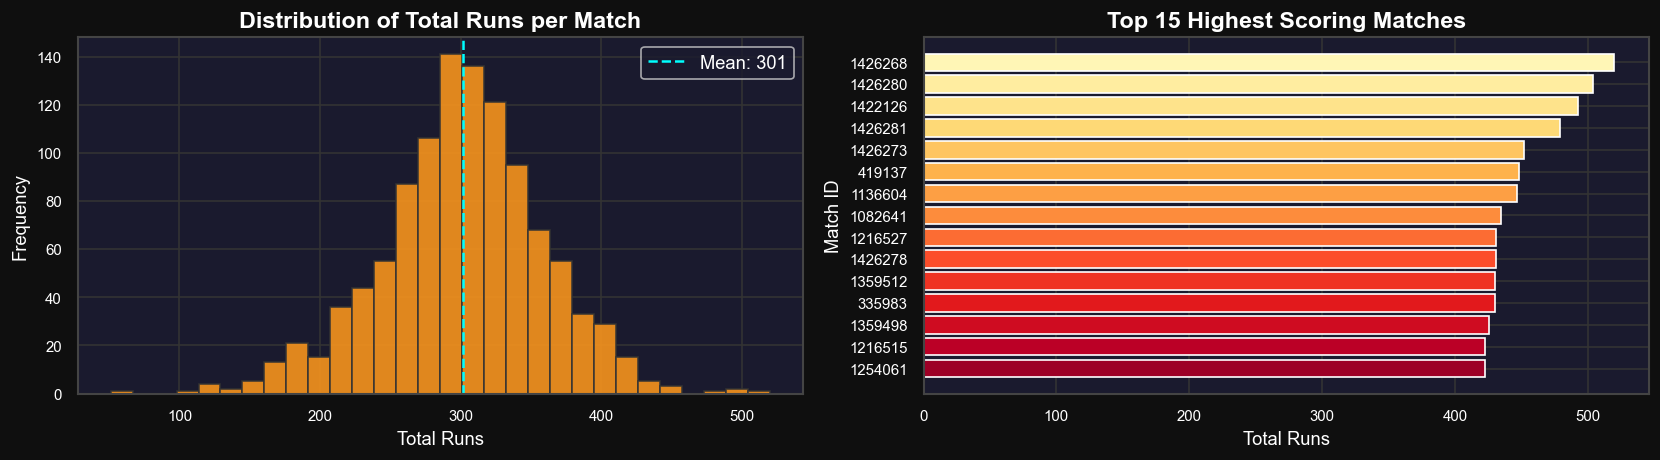

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of match totals
axes[0].hist(runs_per_match['total_runs'], bins=30, color=IPL_COLORS[0],
             edgecolor='#333', alpha=0.9)
axes[0].axvline(runs_per_match['total_runs'].mean(), color='cyan',
                linestyle='--', linewidth=1.5, label=f'Mean: {runs_per_match["total_runs"].mean():.0f}')
axes[0].set_title('Distribution of Total Runs per Match')
axes[0].set_xlabel('Total Runs')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Top 15 highest scoring matches
top15 = runs_per_match.head(15)
axes[1].barh(top15['match_id'].astype(str), top15['total_runs'],
             color=sns.color_palette('YlOrRd', 15))
axes[1].set_title('Top 15 Highest Scoring Matches')
axes[1].set_xlabel('Total Runs')
axes[1].set_ylabel('Match ID')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()